# Fine-tune Qwen2.5-0.5B-Instruct Menggunakan QLoRA

Google Colab: pilih **Runtime > Change runtime type > T4 GPU**, lalu jalankan sel berurutan.
Gunakan runtime baru. Jika library sudah terimpor sebelum instalasi, restart session setelah sel instalasi.
Dataset GadaiKita bersifat sintetis; informasi layanan di dalamnya adalah fiktif.
Output sengaja dikosongkan dan akan muncul setelah notebook dijalankan.

## 1. Instalasi dan konfigurasi

In [1]:
%pip install -q transformers==4.56.2 peft==0.17.1 bitsandbytes==0.47.0 trl==0.23.1 datasets==4.1.1 accelerate==1.10.1 pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.6/564.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.6/503.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 18.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not 

In [2]:
import gc
import json
import time
import shutil
from pathlib import Path
from importlib.metadata import version

import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTConfig, SFTTrainer

assert torch.cuda.is_available(), 'Aktifkan GPU di pengaturan runtime Colab.'
MODEL_ID = 'Qwen/Qwen2.5-0.5B-Instruct'
SEED = 42
MAX_LENGTH = 512
MAX_STEPS = 30  # Budget optimizer steps sama untuk semua eksperimen.
OUTPUT_ROOT = Path('/content/finetune-qwen-qlora')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
# BF16 harus didukung hardware, bukan hanya emulasi (T4 memakai FP16).
def select_compute_dtype():
    native_bf16 = torch.cuda.is_bf16_supported(including_emulation=False)
    return torch.bfloat16 if native_bf16 else torch.float16

COMPUTE_DTYPE = select_compute_dtype()
set_seed(SEED)
print('GPU:', torch.cuda.get_device_name(0))
print('Compute dtype:', COMPUTE_DTYPE)
print('VRAM total (GiB):', round(torch.cuda.get_device_properties(0).total_memory / 2**30, 2))
versions = {p: version(p) for p in ['torch', 'transformers', 'peft', 'bitsandbytes', 'trl', 'datasets', 'accelerate']}
display(pd.DataFrame(versions.items(), columns=['library', 'version']))
(OUTPUT_ROOT / 'environment.json').write_text(json.dumps(versions, indent=2))

GPU: Tesla T4
Compute dtype: torch.float16
VRAM total (GiB): 14.56


,library,version
0,torch,2.11.0+cu128
1,transformers,4.56.2
2,peft,0.17.1
3,bitsandbytes,0.47.0
4,trl,0.23.1
5,datasets,4.1.1
6,accelerate,1.10.1


173

## 2. Dataset training dan prompt evaluasi

In [3]:
from datasets import Dataset
import random

random.seed(42)

SALAM = "Halo, terima kasih telah menghubungi GadaiKita."
PENUTUP = "Ada lagi yang bisa kami bantu?"

def jawaban(inti):
    return f"{SALAM} {inti} {PENUTUP}"

# Basis pengetahuan tanya-jawab (skenario layanan pelanggan GadaiKita)
qa_pairs = [
    ("Apa syarat mengajukan gadai emas?",
     "Syaratnya cukup KTP asli dan barang emas yang akan digadaikan; proses dapat dilakukan di seluruh cabang GadaiKita."),
    ("Berapa lama proses pencairan dana gadai?",
     "Proses pencairan dana di GadaiKita rata-rata hanya 15 menit setelah taksiran barang disetujui."),
    ("Apakah barang saya aman selama digadaikan?",
     "Barang Anda disimpan di ruang khusus berstandar keamanan tinggi dan diasuransikan penuh selama masa gadai."),
    ("Bagaimana cara memperpanjang masa gadai?",
     "Perpanjangan dapat dilakukan dengan membayar biaya pemeliharaan di cabang atau melalui aplikasi GadaiKita sebelum jatuh tempo."),
    ("Berapa bunga atau biaya gadai per bulan?",
     "Biaya pemeliharaan GadaiKita mulai dari 1 persen per 15 hari, tergantung golongan pinjaman."),
    ("Apakah bisa menebus barang sebelum jatuh tempo?",
     "Tentu bisa; Anda dapat menebus barang kapan saja dan biaya hanya dihitung sesuai masa pakai."),
    ("Barang apa saja yang bisa digadaikan?",
     "GadaiKita menerima emas, perhiasan, kendaraan bermotor, serta barang elektronik tertentu."),
    ("Bagaimana jika saya terlambat membayar?",
     "Ada masa tenggang; jika melewati batas, barang akan dilelang dan kelebihan hasil lelang dikembalikan kepada Anda."),
    ("Apakah ada aplikasi untuk cek status gadai?",
     "Ada; unduh aplikasi GadaiKita untuk memantau status gadai, jatuh tempo, dan pembayaran secara online."),
    ("Bisakah gadai diwakilkan orang lain?",
     "Pengajuan gadai harus dilakukan pemilik barang, namun pembayaran cicilan dapat diwakilkan."),
]

# Variasi cara bertanya agar model belajar pola, bukan menghafal kalimat
VARIASI = [
    "{q}", "{q} Mohon infonya.", "Mau tanya, {q_lower}",
    "Permisi, {q_lower}", "{q} Terima kasih.", "Halo kak, {q_lower}",
]


def make_dataset(n_examples=60):
    # Urutan per variasi memastikan 10 contoh mencakup seluruh 10 topik.
    rows = []
    for v in VARIASI:
        for q, a in qa_pairs:
            rows.append({
                'prompt': [{'role': 'user', 'content': v.format(q=q, q_lower=q[0].lower() + q[1:])}],
                'completion': [{'role': 'assistant', 'content': jawaban(a)}],
            })
    assert 1 <= n_examples <= len(rows)
    return Dataset.from_list(rows[:n_examples]).shuffle(seed=SEED)

EVAL_PROMPTS = [
    'Dokumen apa yang perlu saya bawa kalau mau menggadaikan perhiasan emas?',
    'Setelah nilai taksiran disepakati, berapa menit sampai uangnya cair?',
    'Bagaimana perlindungan barang titipan saya di tempat kalian?',
    'Kalau masa gadai hampir habis, bagaimana memperpanjangnya?',
    'Berapa tarif pemeliharaan yang dikenakan untuk pinjaman?',
    'Boleh melunasi pinjaman dan mengambil barang lebih cepat?',
    'Selain emas, jenis barang apa yang kalian terima?',
    'Apa yang terjadi pada barang jaminan jika pembayaran melewati tenggat?',
    'Saya ingin memantau jatuh tempo lewat ponsel, caranya bagaimana?',
    'Apakah saudara saya boleh mengajukan gadai atas nama saya?',
]
OOD_PROMPTS = ['Apakah kantor buka hari Minggu?', 'Berapa harga emas hari ini?']
dataset = make_dataset()
train_prompts = {row['prompt'][0]['content'] for row in dataset}
assert not train_prompts.intersection(EVAL_PROMPTS + OOD_PROMPTS)
print('Training:', len(dataset), '| Evaluasi parafrasa:', len(EVAL_PROMPTS))
display(pd.DataFrame([{'pertanyaan': r['prompt'][0]['content'], 'jawaban': r['completion'][0]['content']} for r in dataset]).head())

Training: 60 | Evaluasi parafrasa: 10


,pertanyaan,jawaban
0,"Mau tanya, apakah ada aplikasi untuk cek statu...","Halo, terima kasih telah menghubungi GadaiKita..."
1,"Halo kak, apakah bisa menebus barang sebelum j...","Halo, terima kasih telah menghubungi GadaiKita..."
2,Apakah ada aplikasi untuk cek status gadai? Mo...,"Halo, terima kasih telah menghubungi GadaiKita..."
3,"Mau tanya, berapa bunga atau biaya gadai per b...","Halo, terima kasih telah menghubungi GadaiKita..."
4,Bagaimana jika saya terlambat membayar?,"Halo, terima kasih telah menghubungi GadaiKita..."


## 3. Model 4-bit, training, dan evaluasi

Evaluasi memakai parafrasa dari topik training, bukan pengujian topik baru.
Metrik format memeriksa salam dan penutup, bukan kebenaran isi jawaban.
Prompt di luar pengetahuan training ditampilkan terpisah untuk diperiksa manual.

In [4]:
def cleanup_gpu():
    gc.collect()
    torch.cuda.empty_cache()

def load_model(model_id):
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = 'right'
    quantization = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    )
    model = AutoModelForCausalLM.from_pretrained(
        model_id, quantization_config=quantization,
        device_map={'': 0}, torch_dtype=COMPUTE_DTYPE,
        attn_implementation='sdpa',
    )
    return model, tokenizer

def generate(model, tokenizer, prompt, max_new_tokens=150):
    model.eval()
    inputs = tokenizer.apply_chat_template(
        [{'role': 'user', 'content': prompt}], add_generation_prompt=True,
        tokenize=True, return_dict=True, return_tensors='pt',
    ).to(model.device)
    # PEFT mempertahankan beberapa bobot di FP32. Generate harus memakai AMP
    # juga, termasuk sesudah training dan saat adapter dimuat ulang.
    with torch.inference_mode(), torch.autocast(device_type=model.device.type, dtype=COMPUTE_DTYPE):
        output = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False,
            temperature=None, top_p=None, top_k=None, use_cache=True,
            pad_token_id=tokenizer.pad_token_id, eos_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(output[0, inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()

def evaluate_outputs(model, tokenizer):
    records = []
    for group, prompts in [('parafrasa', EVAL_PROMPTS), ('di_luar_dataset', OOD_PROMPTS)]:
        for prompt in prompts:
            answer = generate(model, tokenizer, prompt)
            records.append({
                'group': group, 'prompt': prompt, 'answer': answer,
                'salam_ok': answer.startswith(SALAM),
                'penutup_ok': answer.endswith(PENUTUP),
                'format_ok': answer.startswith(SALAM) and answer.endswith(PENUTUP),
            })
    return pd.DataFrame(records)

def format_score(frame):
    return float(frame.loc[frame.group == 'parafrasa', 'format_ok'].mean())

def run_experiment(name, model_id=MODEL_ID, rank=16, n_examples=60):
    cleanup_gpu()
    set_seed(SEED)
    run_dir = OUTPUT_ROOT / name
    run_dir.mkdir(parents=True, exist_ok=True)
    model = tokenizer = trainer = None
    try:
        model, tokenizer = load_model(model_id)
        base_memory = model.get_memory_footprint() / 2**30
        before = evaluate_outputs(model, tokenizer)
        model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
        model.config.use_cache = False
        model = get_peft_model(model, LoraConfig(
            r=rank, lora_alpha=2 * rank, lora_dropout=0.05,
            target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
            bias='none', task_type='CAUSAL_LM',
        ))
        trainable, total = model.get_nb_trainable_parameters()
        model.print_trainable_parameters()
        train_data = make_dataset(n_examples)
        # Hindari terpotongnya target jawaban tanpa disadari.
        lengths = [len(tokenizer.apply_chat_template(r['prompt'] + r['completion'], tokenize=True)) for r in train_data]
        assert max(lengths) <= MAX_LENGTH, 'Naikkan MAX_LENGTH agar target tidak terpotong.'
        config = SFTConfig(
            output_dir=str(run_dir / 'checkpoints'), max_steps=MAX_STEPS,
            per_device_train_batch_size=1, gradient_accumulation_steps=8,
            learning_rate=2e-4, lr_scheduler_type='cosine', warmup_ratio=0.05,
            logging_steps=5, logging_first_step=True, save_strategy='no',
            optim='paged_adamw_8bit', max_length=MAX_LENGTH,
            completion_only_loss=True, packing=False,
            eos_token=tokenizer.eos_token, pad_token=tokenizer.pad_token,
            fp16=COMPUTE_DTYPE == torch.float16, bf16=COMPUTE_DTYPE == torch.bfloat16,
            gradient_checkpointing=True, gradient_checkpointing_kwargs={'use_reentrant': False},
            report_to='none', seed=SEED, data_seed=SEED,
        )
        trainer = SFTTrainer(model=model, args=config, train_dataset=train_data, processing_class=tokenizer)
        # Periksa jalur inference dengan adapter sebelum training panjang dimulai.
        print('Cek inference adapter:', generate(model, tokenizer, EVAL_PROMPTS[0], max_new_tokens=2))
        model.train()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        start = time.perf_counter()
        training = trainer.train()
        torch.cuda.synchronize()
        seconds = time.perf_counter() - start
        peak_allocated = torch.cuda.max_memory_allocated() / 2**30
        peak_reserved = torch.cuda.max_memory_reserved() / 2**30
        adapter_dir = run_dir / 'adapter'
        trainer.save_model(str(adapter_dir))
        tokenizer.save_pretrained(adapter_dir)
        # Simpan log dan metrik training sebelum evaluasi agar tetap tersedia
        # jika session terputus atau evaluasi gagal.
        logs = pd.DataFrame(trainer.state.log_history)
        logs.to_csv(run_dir / 'training_log.csv', index=False)
        training_metrics = dict(
            experiment=name, model_id=model_id, rank=rank, n_examples=n_examples,
            max_steps=MAX_STEPS, actual_steps=trainer.state.global_step,
            training_loss=float(training.training_loss), train_seconds=seconds,
            compute_dtype=str(COMPUTE_DTYPE),
            peak_train_allocated_GiB=peak_allocated, peak_train_reserved_GiB=peak_reserved,
        )
        (run_dir / 'training_metrics.json').write_text(json.dumps(training_metrics, indent=2))
        model.gradient_checkpointing_disable()
        model.config.use_cache = True
        after = evaluate_outputs(model, tokenizer)
        comparison = before[['group', 'prompt', 'answer']].rename(columns={'answer': 'before'})
        comparison['after'] = after.answer
        comparison['format_ok_after'] = after.format_ok
        comparison.to_csv(run_dir / 'predictions.csv', index=False)
        metrics = dict(
            experiment=name, model_id=model_id, rank=rank, n_examples=n_examples,
            compute_dtype=str(COMPUTE_DTYPE),
            max_steps=MAX_STEPS, actual_steps=trainer.state.global_step,
            trainable_parameters=trainable, trainable_percent=100 * trainable / total,
            training_loss=float(training.training_loss), train_seconds=seconds,
            base_model_GiB=base_memory, peak_train_allocated_GiB=peak_allocated,
            peak_train_reserved_GiB=peak_reserved,
            format_before=format_score(before), format_after=format_score(after),
            adapter_dir=str(adapter_dir),
        )
        (run_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2))
        display(pd.DataFrame([metrics]))
        for row in comparison.itertuples():
            print(f'\n[{row.group}] {row.prompt}\nSEBELUM: {row.before}\nSESUDAH: {row.after}')
        if 'loss' in logs.columns:
            logs.dropna(subset=['loss']).plot(x='step', y='loss', marker='o', title=name)
            plt.show()
        return metrics, comparison
    finally:
        if trainer is not None:
            trainer.accelerator.free_memory()
        del trainer, model, tokenizer
        cleanup_gpu()

## 4. Fine-tuning utama: Qwen2.5-0.5B, rank 16, 60 contoh

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Cek inference adapter: Tent


Step,Training Loss
1,2.781500
5,2.024200
10,0.930600
15,0.370400
20,0.114500
25,0.032900
30,0.017600


,experiment,model_id,rank,n_examples,compute_dtype,max_steps,actual_steps,trainable_parameters,trainable_percent,training_loss,train_seconds,base_model_GiB,peak_train_allocated_GiB,peak_train_reserved_GiB,format_before,format_after,adapter_dir
0,qwen05b_r16_n60,Qwen/Qwen2.5-0.5B-Instruct,16,60,torch.float16,30,30,8798208,1.749735,0.606929,155.267728,0.42033,1.356828,1.728516,0.0,1.0,/content/finetune-qwen-qlora/qwen05b_r16_n60/a...



[parafrasa] Dokumen apa yang perlu saya bawa kalau mau menggadaikan perhiasan emas?
SEBELUM: Tentu saja, berikut adalah beberapa dokumen yang bisa Anda gunakan untuk menggadaikan perhiasan emas:

1. Perhiasan emas: Anda dapat memilih dari berbagai jenis perhiasan emas seperti emas 24K, emas 25K, atau emas 30K.

2. Kebutukan: Jika Anda ingin menambahkan kebutan pada perhiasan emas tersebut, Anda dapat menggunakan kemasan khusus seperti kemasan emas 24K, emas 25K, atau emas 30K.

3. Pakaian: Anda juga dapat mencoba pakaian dengan
SESUDAH: Halo, terima kasih telah menghubungi GadaiKita. Dokumen yang perlu Anda bawa adalah pemeliharaan perhiasan, serta barang khusus perhiasan emas yang akan digadai. Ada lagi yang bisa kami bantu?

[parafrasa] Setelah nilai taksiran disepakati, berapa menit sampai uangnya cair?
SEBELUM: Untuk informasi tentang waktu sampai uang Anda cair, saya harus memeriksa data yang telah tersedia dalam sistem. Namun, jika Anda memiliki data yang lebih lanjut atau perin

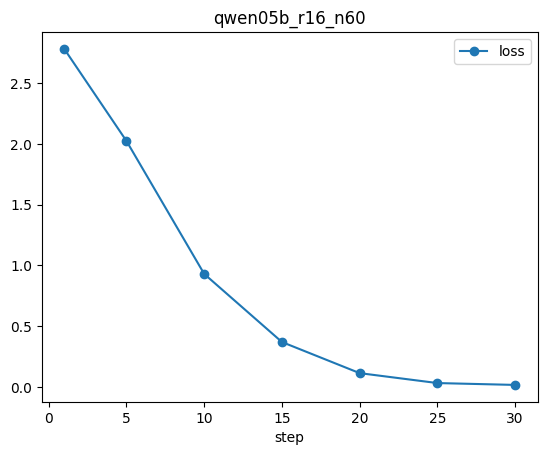

In [5]:
main_metrics, main_predictions = run_experiment('qwen05b_r16_n60')
results = [main_metrics]

## 5. Eksperimen rank, ukuran dataset, dan ukuran model

Semua eksperimen aktif saat Run all. Ubah flag menjadi `False` untuk melewati kelompok tertentu.
Setiap run memuat base model baru dan membebaskan memori sesudahnya.
Budget training sama: 30 optimizer steps, batch efektif 8; dataset 10 contoh akan diulang lebih sering.
Eksperimen 1.5B membutuhkan unduhan, waktu, dan VRAM lebih besar.

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 2,199,552 || all params: 496,232,320 || trainable%: 0.4433


Tokenizing train dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Cek inference adapter: Tent


Step,Training Loss
1,2.781500
5,2.458500
10,1.845500
15,1.109000
20,0.802400
25,0.653900
30,0.599100


,experiment,model_id,rank,n_examples,compute_dtype,max_steps,actual_steps,trainable_parameters,trainable_percent,training_loss,train_seconds,base_model_GiB,peak_train_allocated_GiB,peak_train_reserved_GiB,format_before,format_after,adapter_dir
0,qwen05b_r4_n60,Qwen/Qwen2.5-0.5B-Instruct,4,60,torch.float16,30,30,2199552,0.44325,1.255511,156.588441,0.42033,1.806756,2.197266,0.0,1.0,/content/finetune-qwen-qlora/qwen05b_r4_n60/ad...



[parafrasa] Dokumen apa yang perlu saya bawa kalau mau menggadaikan perhiasan emas?
SEBELUM: Tentu saja, berikut adalah beberapa dokumen yang bisa Anda gunakan untuk menggadaikan perhiasan emas:

1. Perhiasan emas: Anda dapat memilih dari berbagai jenis perhiasan emas seperti emas 24K, emas 25K, atau emas 30K.

2. Kebutukan: Jika Anda ingin menambahkan kebutan pada perhiasan emas tersebut, Anda dapat menggunakan kemasan khusus seperti kemasan emas 24K, emas 25K, atau emas 30K.

3. Pakaian: Anda juga dapat mencoba pakaian dengan
SESUDAH: Halo, terima kasih telah menghubungi GadaiKita. Ada lagi yang bisa kami bantu?

[parafrasa] Setelah nilai taksiran disepakati, berapa menit sampai uangnya cair?
SEBELUM: Untuk informasi tentang waktu sampai uang Anda cair, saya harus memeriksa data yang telah tersedia dalam sistem. Namun, jika Anda memiliki data yang lebih lanjut atau perintah yang dapat membantu, saya akan mencoba membantu Anda menghitung waktu sampai uang Anda cair.

Namun, sebaiknya

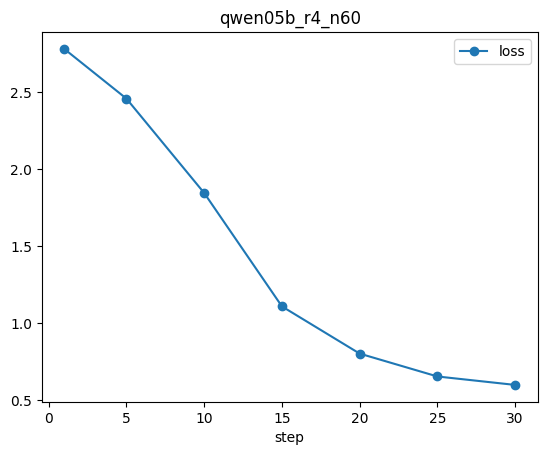

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 35,192,832 || all params: 529,225,600 || trainable%: 6.6499


Tokenizing train dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Cek inference adapter: Tent


Step,Training Loss
1,2.781500
5,1.634800
10,0.427500
15,0.050800
20,0.003100
25,0.001600
30,0.001200


,experiment,model_id,rank,n_examples,compute_dtype,max_steps,actual_steps,trainable_parameters,trainable_percent,training_loss,train_seconds,base_model_GiB,peak_train_allocated_GiB,peak_train_reserved_GiB,format_before,format_after,adapter_dir
0,qwen05b_r64_n60,Qwen/Qwen2.5-0.5B-Instruct,64,60,torch.float16,30,30,35192832,6.649873,0.391398,151.483715,0.42033,2.626672,2.902344,0.0,1.0,/content/finetune-qwen-qlora/qwen05b_r64_n60/a...



[parafrasa] Dokumen apa yang perlu saya bawa kalau mau menggadaikan perhiasan emas?
SEBELUM: Tentu saja, berikut adalah beberapa dokumen yang bisa Anda gunakan untuk menggadaikan perhiasan emas:

1. Perhiasan emas: Anda dapat memilih dari berbagai jenis perhiasan emas seperti emas 24K, emas 25K, atau emas 30K.

2. Kebutukan: Jika Anda ingin menambahkan kebutan pada perhiasan emas tersebut, Anda dapat menggunakan kemasan khusus seperti kemasan emas 24K, emas 25K, atau emas 30K.

3. Pakaian: Anda juga dapat mencoba pakaian dengan
SESUDAH: Halo, terima kasih telah menghubungi GadaiKita. Perhiasan emas dapat dijatuhkan di seluruh cabang GadaiKita dan biaya hanya dihitung sesuai masa pakai. Ada lagi yang bisa kami bantu?

[parafrasa] Setelah nilai taksiran disepakati, berapa menit sampai uangnya cair?
SEBELUM: Untuk informasi tentang waktu sampai uang Anda cair, saya harus memeriksa data yang telah tersedia dalam sistem. Namun, jika Anda memiliki data yang lebih lanjut atau perintah yang d

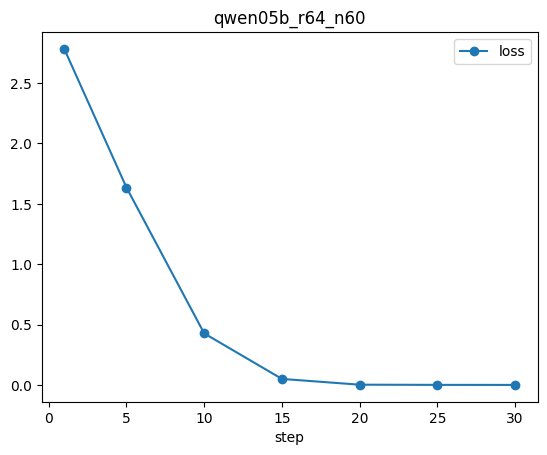

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


Tokenizing train dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Cek inference adapter: Tent


Step,Training Loss
1,2.912400
5,2.623800
10,1.014000
15,0.404500
20,0.171900
25,0.036800
30,0.015500


,experiment,model_id,rank,n_examples,compute_dtype,max_steps,actual_steps,trainable_parameters,trainable_percent,training_loss,train_seconds,base_model_GiB,peak_train_allocated_GiB,peak_train_reserved_GiB,format_before,format_after,adapter_dir
0,qwen05b_r16_n10,Qwen/Qwen2.5-0.5B-Instruct,16,10,torch.float16,30,30,8798208,1.749735,0.72073,102.990013,0.42033,2.861585,3.261719,0.0,1.0,/content/finetune-qwen-qlora/qwen05b_r16_n10/a...



[parafrasa] Dokumen apa yang perlu saya bawa kalau mau menggadaikan perhiasan emas?
SEBELUM: Tentu saja, berikut adalah beberapa dokumen yang bisa Anda gunakan untuk menggadaikan perhiasan emas:

1. Perhiasan emas: Anda dapat memilih dari berbagai jenis perhiasan emas seperti emas 24K, emas 25K, atau emas 30K.

2. Kebutukan: Jika Anda ingin menambahkan kebutan pada perhiasan emas tersebut, Anda dapat menggunakan kemasan khusus seperti kemasan emas 24K, emas 25K, atau emas 30K.

3. Pakaian: Anda juga dapat mencoba pakaian dengan
SESUDAH: Halo, terima kasih telah menghubungi GadaiKita. Ada; unduh aplikasi GadaiKita untuk membawa ke cabang untuk perhiasan emas. Ada lagi yang bisa kami bantu?

[parafrasa] Setelah nilai taksiran disepakati, berapa menit sampai uangnya cair?
SEBELUM: Untuk informasi tentang waktu sampai uang Anda cair, saya harus memeriksa data yang telah tersedia dalam sistem. Namun, jika Anda memiliki data yang lebih lanjut atau perintah yang dapat membantu, saya akan men

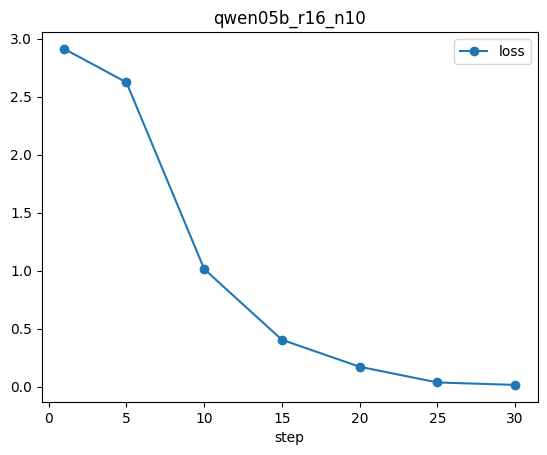

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

...

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Cek inference adapter: Untuk


Step,Training Loss
1,2.545800
5,1.912800
10,0.854800
15,0.289100
20,0.058900
25,0.016700
30,0.008300


,experiment,model_id,rank,n_examples,compute_dtype,max_steps,actual_steps,trainable_parameters,trainable_percent,training_loss,train_seconds,base_model_GiB,peak_train_allocated_GiB,peak_train_reserved_GiB,format_before,format_after,adapter_dir
0,qwen15b_r16_n60,Qwen/Qwen2.5-1.5B-Instruct,16,60,torch.float16,30,30,18464768,1.181988,0.544535,181.554067,1.04507,4.47408,4.824219,0.0,1.0,/content/finetune-qwen-qlora/qwen15b_r16_n60/a...



[parafrasa] Dokumen apa yang perlu saya bawa kalau mau menggadaikan perhiasan emas?
SEBELUM: Untuk menggadaikan perhiasan emas, Anda biasanya memerlukan beberapa dokumen penting untuk melengkapi proses pengadaan dan pembayaran. Berikut adalah daftar yang mungkin perlu:

1. Surat Keterangan Asal (SKA): Ini adalah surat yang dikeluarkan oleh pihak bank atau kantor pajak yang menunjukkan bahwa barang tersebut merupakan hasil dari investasi atau perdagangan.

2. Surat Keterangan Asal Perusahaan: Jika perhiasan ini dibeli dari sebuah perusahaan, Anda mungkin perlu membawakan surat ini sebagai bukti asalnya.

3. Surat Keterangan Asal
SESUDAH: Halo, terima kasih telah menghubungi GadaiKita. Anda hanya perlu membawa barang emas yang akan digadaikan; proses dapat dilakukan di seluruh cabang GadaiKita. Ada lagi yang bisa kami bantu?

[parafrasa] Setelah nilai taksiran disepakati, berapa menit sampai uangnya cair?
SEBELUM: Untuk menjawab pertanyaan ini dengan tepat, saya memerlukan informasi leb

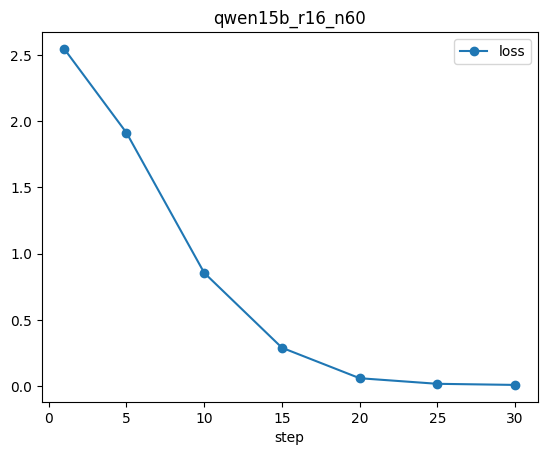

In [6]:
RUN_RANK_EXPERIMENTS = True
RUN_SMALL_DATASET = True
RUN_LARGER_MODEL = True

experiments = []
if RUN_RANK_EXPERIMENTS:
    experiments += [dict(name=f'qwen05b_r{rank}_n60', rank=rank) for rank in [4, 64]]
if RUN_SMALL_DATASET:
    experiments.append(dict(name='qwen05b_r16_n10', n_examples=10))
if RUN_LARGER_MODEL:
    experiments.append(dict(name='qwen15b_r16_n60', model_id='Qwen/Qwen2.5-1.5B-Instruct'))

results = [main_metrics]  # Aman menjalankan ulang sel eksperimen tanpa duplikasi tabel.
for experiment in experiments:
    metrics, predictions = run_experiment(**experiment)
    results.append(metrics)
    pd.DataFrame(results).to_csv(OUTPUT_ROOT / 'experiment_metrics.csv', index=False)

## 6. Perbandingan hasil eksperimen

,experiment,model_id,rank,n_examples,compute_dtype,max_steps,actual_steps,trainable_parameters,trainable_percent,training_loss,train_seconds,base_model_GiB,peak_train_allocated_GiB,peak_train_reserved_GiB,format_before,format_after
0,qwen05b_r16_n60,Qwen/Qwen2.5-0.5B-Instruct,16,60,torch.float16,30,30,8798208,1.749735,0.606929,155.267728,0.42033,1.356828,1.728516,0.0,1.0
1,qwen05b_r4_n60,Qwen/Qwen2.5-0.5B-Instruct,4,60,torch.float16,30,30,2199552,0.443250,1.255511,156.588441,0.42033,1.806756,2.197266,0.0,1.0
2,qwen05b_r64_n60,Qwen/Qwen2.5-0.5B-Instruct,64,60,torch.float16,30,30,35192832,6.649873,0.391398,151.483715,0.42033,2.626672,2.902344,0.0,1.0
3,qwen05b_r16_n10,Qwen/Qwen2.5-0.5B-Instruct,16,10,torch.float16,30,30,8798208,1.749735,0.720730,102.990013,0.42033,2.861585,3.261719,0.0,1.0
4,qwen15b_r16_n60,Qwen/Qwen2.5-1.5B-Instruct,16,60,torch.float16,30,30,18464768,1.181988,0.544535,181.554067,1.04507,4.474080,4.824219,0.0,1.0


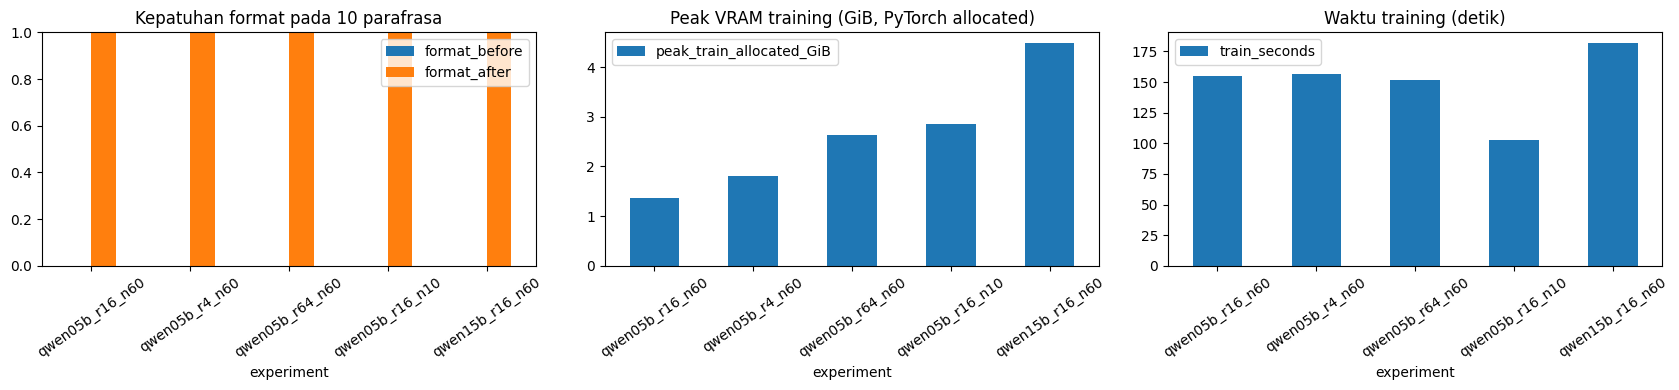

In [7]:
summary = pd.DataFrame(results)
summary.to_csv(OUTPUT_ROOT / 'experiment_metrics.csv', index=False)
display(summary.drop(columns=['adapter_dir']))
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, cols, title in [
    (axes[0], ['format_before', 'format_after'], 'Kepatuhan format pada 10 parafrasa'),
    (axes[1], ['peak_train_allocated_GiB'], 'Peak VRAM training (GiB, PyTorch allocated)'),
    (axes[2], ['train_seconds'], 'Waktu training (detik)'),
]:
    summary.set_index('experiment')[cols].plot.bar(ax=ax, title=title, rot=35)
axes[0].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Muat ulang adapter utama dan verifikasi output

In [8]:
cleanup_gpu()
adapter_dir = main_metrics['adapter_dir']
reloaded, _ = load_model(MODEL_ID)
reloaded_tokenizer = AutoTokenizer.from_pretrained(adapter_dir)
reloaded = PeftModel.from_pretrained(reloaded, adapter_dir)
try:
    prompt = EVAL_PROMPTS[0]
    answer = generate(reloaded, reloaded_tokenizer, prompt)
    expected = main_predictions.loc[main_predictions.prompt == prompt, 'after'].iloc[0]
    print('Prompt:', prompt)
    print('Sebelum disimpan:', expected)
    print('Setelah dimuat ulang:', answer)
    print('Output identik:', answer == expected)
finally:
    del reloaded, reloaded_tokenizer
    cleanup_gpu()

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Prompt: Dokumen apa yang perlu saya bawa kalau mau menggadaikan perhiasan emas?
Sebelum disimpan: Halo, terima kasih telah menghubungi GadaiKita. Dokumen yang perlu Anda bawa adalah pemeliharaan perhiasan, serta barang khusus perhiasan emas yang akan digadai. Ada lagi yang bisa kami bantu?
Setelah dimuat ulang: Halo, terima kasih telah menghubungi GadaiKita. Dokumen yang perlu Anda bawa adalah pemeliharaan perhiasan, serta barang khusus perhiasan emas yang akan digadai. Ada lagi yang bisa kami bantu?
Output identik: True


## 8. Ekspor adapter dan hasil

ZIP berisi adapter tiap eksperimen, tokenizer, CSV jawaban, log training, metrik, dan grafik.
Untuk menyimpan notebook beserta output, gunakan **File > Download > Download .ipynb** setelah selesai.

In [9]:
archive = shutil.make_archive('/content/finetune-qwen-qlora-results', 'zip', OUTPUT_ROOT)
print('Arsip:', archive)
DOWNLOAD_RESULTS = True
if DOWNLOAD_RESULTS:
    from google.colab import files
    files.download(archive)

Arsip: /content/finetune-qwen-qlora-results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Referensi API: [Qwen2.5](https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct),
[TRL 0.23.1](https://huggingface.co/docs/trl/v0.23.1/en/sft_trainer),
[PEFT quantization](https://huggingface.co/docs/peft/developer_guides/quantization).